In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_recall_curve, roc_curve, 
                             roc_auc_score, average_precision_score)

In [2]:
RANDOM_STATE = 4200

# OUTDIR DIR
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# reading files: q60, q70,q80
q60_df = pd.read_csv("datasets/predicted_associations/CF_scores/predicted_multi_n_scores_new4_Thr_0p05_Q60_finer.csv", sep=',')
q70_df = pd.read_csv("datasets/predicted_associations/CF_scores/predicted_multi_n_scores_new4_Thr_0p05_Q70_finer.csv", sep=',')
q80_df = pd.read_csv("datasets/predicted_associations/CF_scores/predicted_multi_n_scores_new4_Thr_0p05_Q80_finer.csv", sep=',')

print(f"Q60: {q60_df.shape}; Q70: {q70_df.shape}; Q80: {q80_df.shape}")

Q60: (77093, 22); Q70: (77093, 22); Q80: (77093, 22)


In [4]:
# identifying score columns
q60_scores = [c for c in q60_df.columns if c.startswith("Score_")]
q70_scores = [c for c in q70_df.columns if c.startswith("Score_")]
q80_scores = [c for c in q80_df.columns if c.startswith("Score_")]

print(f"\nNumber of score features per Q = Q60: {len(q60_scores)}; Q70: {len(q70_scores)}; Q80: {len(q80_scores)}")


Number of score features per Q = Q60: 20; Q70: 20; Q80: 20


In [5]:
# concatenate scores column-wise
concatenated_scores = pd.concat([
        q60_df[["MiRNA", "Disease"] + q60_scores],
        q70_df[q70_scores],
        q80_df[q80_scores],
    ],
    axis=1
)

# final feature columns
score_columns = [
    c for c in concatenated_scores.columns
    if c.startswith("Score_")
]

print("\nCombined shape:", concatenated_scores.shape)
print("Candidate pairs:", len(concatenated_scores))
print("Total score features:", len(score_columns))

display(concatenated_scores.head())
concatenated_scores.to_csv("datasets/predicted_associations/CF_scores/predicted_multi_n_scores_Q60_Q70_Q80_finer_combined.csv", index=False)


Combined shape: (77093, 62)
Candidate pairs: 77093
Total score features: 60


,MiRNA,Disease,Score_top60_n5,Score_top60_n10,Score_top60_n15,Score_top60_n20,Score_top60_n25,Score_top60_n30,Score_top60_n35,Score_top60_n40,...,Score_top80_n55,Score_top80_n60,Score_top80_n65,Score_top80_n70,Score_top80_n75,Score_top80_n80,Score_top80_n85,Score_top80_n90,Score_top80_n95,Score_top80_n100
0,59,204,0.00000,0.00000,0.000000,1.286659,3.051776,4.815843,5.512730,6.864878,...,9.458919,11.058926,12.462831,12.811274,14.216766,15.849182,17.178504,18.303300,19.761201,21.716246
1,138,178,0.00000,0.00000,0.438589,1.257252,1.629719,2.004347,2.370920,3.671019,...,13.220571,14.202988,15.232496,17.048826,17.448604,19.645204,20.293730,21.820341,23.504380,25.719996
2,52,316,0.00000,0.00000,0.000000,0.000000,0.000000,2.262837,2.856937,4.461440,...,8.629549,11.085643,11.533016,18.273224,18.678954,22.304785,29.255941,31.163308,36.609290,42.374705
3,42,194,0.52844,0.52844,0.528440,0.528440,1.056879,1.056879,1.980629,4.939804,...,6.871193,8.149175,8.699065,10.823418,11.943606,12.671236,18.017861,21.700177,24.654024,27.519062
4,52,311,0.00000,0.00000,0.601543,1.174679,1.174679,1.174679,2.329208,2.802964,...,5.319683,6.975726,8.325374,14.909940,16.514108,17.806457,20.160429,21.224722,24.536006,26.086276


In [6]:
# final score features
df = pd.read_csv("datasets/predicted_associations/CF_scores/predicted_multi_n_scores_Q60_Q70_Q80_finer_combined.csv")
display(df)

,MiRNA,Disease,Score_top60_n5,Score_top60_n10,Score_top60_n15,Score_top60_n20,Score_top60_n25,Score_top60_n30,Score_top60_n35,Score_top60_n40,...,Score_top80_n55,Score_top80_n60,Score_top80_n65,Score_top80_n70,Score_top80_n75,Score_top80_n80,Score_top80_n85,Score_top80_n90,Score_top80_n95,Score_top80_n100
0,59,204,0.00000,0.00000,0.000000,1.286659,3.051776,4.815843,5.512730,6.864878,...,9.458919,11.058926,12.462831,12.811274,14.216766,15.849182,17.178504,18.303300,19.761201,21.716246
1,138,178,0.00000,0.00000,0.438589,1.257252,1.629719,2.004347,2.370920,3.671019,...,13.220571,14.202988,15.232496,17.048826,17.448604,19.645204,20.293730,21.820341,23.504380,25.719996
2,52,316,0.00000,0.00000,0.000000,0.000000,0.000000,2.262837,2.856937,4.461440,...,8.629549,11.085643,11.533016,18.273224,18.678954,22.304785,29.255941,31.163308,36.609290,42.374705
3,42,194,0.52844,0.52844,0.528440,0.528440,1.056879,1.056879,1.980629,4.939804,...,6.871193,8.149175,8.699065,10.823418,11.943606,12.671236,18.017861,21.700177,24.654024,27.519062
4,52,311,0.00000,0.00000,0.601543,1.174679,1.174679,1.174679,2.329208,2.802964,...,5.319683,6.975726,8.325374,14.909940,16.514108,17.806457,20.160429,21.224722,24.536006,26.086276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77088,493,67,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.545788,0.545788,0.545788,0.545788,0.545788,0.545788,0.545788,0.545788,0.545788
77089,493,354,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.723693,0.723693,0.723693,0.723693,0.723693,0.723693,0.723693
77090,435,185,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.218173,0.218173,0.218173
77091,404,172,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.674406


In [7]:
# analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77093 entries, 0 to 77092
Data columns (total 62 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MiRNA             77093 non-null  int64  
 1   Disease           77093 non-null  int64  
 2   Score_top60_n5    77093 non-null  float64
 3   Score_top60_n10   77093 non-null  float64
 4   Score_top60_n15   77093 non-null  float64
 5   Score_top60_n20   77093 non-null  float64
 6   Score_top60_n25   77093 non-null  float64
 7   Score_top60_n30   77093 non-null  float64
 8   Score_top60_n35   77093 non-null  float64
 9   Score_top60_n40   77093 non-null  float64
 10  Score_top60_n45   77093 non-null  float64
 11  Score_top60_n50   77093 non-null  float64
 12  Score_top60_n55   77093 non-null  float64
 13  Score_top60_n60   77093 non-null  float64
 14  Score_top60_n65   77093 non-null  float64
 15  Score_top60_n70   77093 non-null  float64
 16  Score_top60_n75   77093 non-null  float6

In [8]:
# analysis
df.describe()

,MiRNA,Disease,Score_top60_n5,Score_top60_n10,Score_top60_n15,Score_top60_n20,Score_top60_n25,Score_top60_n30,Score_top60_n35,Score_top60_n40,...,Score_top80_n55,Score_top80_n60,Score_top80_n65,Score_top80_n70,Score_top80_n75,Score_top80_n80,Score_top80_n85,Score_top80_n90,Score_top80_n95,Score_top80_n100
count,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,...,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000,77093.000000
mean,254.155137,191.245184,0.137735,0.419325,0.767597,1.193306,1.623597,2.124682,2.620402,3.169254,...,4.924539,5.520807,6.126170,6.671192,7.289273,7.964767,8.662649,9.323391,10.056208,10.763560
std,143.579556,108.514556,0.601392,1.435902,2.320018,3.350642,4.363534,5.467570,6.555209,7.659362,...,10.987116,11.997019,13.011396,13.951268,14.892577,15.879066,16.821839,17.708210,18.664978,19.593724
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,127.000000,96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.333116,0.445539,0.502565,0.550533,0.584453
50%,259.000000,194.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.628476,0.688882,0.723693,0.723693,0.772902,0.868430,1.034387,1.171252,1.277902,1.381469
75%,374.000000,285.000000,0.000000,0.000000,0.414794,0.702809,1.040605,1.541752,1.989722,2.539637,...,5.054920,5.998260,6.932128,7.823427,8.941878,10.000011,11.063940,12.216342,13.365833,14.394403
max,494.000000,381.000000,16.598237,31.348758,35.000658,41.397708,55.323353,63.170356,70.531150,76.788765,...,102.968436,112.859992,119.176946,123.712900,133.154148,141.462336,146.986240,156.686360,164.129285,173.336222


In [9]:
#loading ground-truths miRNA-disease associations

GROUND_TRUTH_FILE = ("datasets/1.miRNA_disease_association/knowndiseasemirnainteraction.txt")
ground_truth = pd.read_csv(GROUND_TRUTH_FILE, sep=r"\s+", header=None, names=["MiRNA", "Disease"])
ground_truth = ground_truth.drop_duplicates()

print("Ground-truth interactions:", len(ground_truth))
print(f"Unique miRNAs: {ground_truth['MiRNA'].nunique()}; diseases: {ground_truth['Disease'].nunique()}")
display(ground_truth.head())

Ground-truth interactions: 5430
Unique miRNAs: 495; diseases: 383


,MiRNA,Disease
0,1,1
1,2,1
2,3,1
3,4,2
4,5,2


In [10]:
# assigning ground-truths from known miRNA-disease associations to CF predictions

known_pairs = ground_truth.assign(Label=1)
df = df.merge(known_pairs, on=["MiRNA", "Disease"], how="left")
df["Label"] = df["Label"].fillna(0).astype(int)

print("Ground-truth label distribution:")
print(df["Label"].value_counts().sort_index())
print(f"\nTotal candidate pairs: {len(df)}; Positive prevalence: {df['Label'].mean():.4f}")

Ground-truth label distribution:
Label
0    75198
1     1895
Name: count, dtype: int64

Total candidate pairs: 77093; Positive prevalence: 0.0246


In [11]:
display(df.head())

,MiRNA,Disease,Score_top60_n5,Score_top60_n10,Score_top60_n15,Score_top60_n20,Score_top60_n25,Score_top60_n30,Score_top60_n35,Score_top60_n40,...,Score_top80_n60,Score_top80_n65,Score_top80_n70,Score_top80_n75,Score_top80_n80,Score_top80_n85,Score_top80_n90,Score_top80_n95,Score_top80_n100,Label
0,59,204,0.00000,0.00000,0.000000,1.286659,3.051776,4.815843,5.512730,6.864878,...,11.058926,12.462831,12.811274,14.216766,15.849182,17.178504,18.303300,19.761201,21.716246,0
1,138,178,0.00000,0.00000,0.438589,1.257252,1.629719,2.004347,2.370920,3.671019,...,14.202988,15.232496,17.048826,17.448604,19.645204,20.293730,21.820341,23.504380,25.719996,0
2,52,316,0.00000,0.00000,0.000000,0.000000,0.000000,2.262837,2.856937,4.461440,...,11.085643,11.533016,18.273224,18.678954,22.304785,29.255941,31.163308,36.609290,42.374705,0
3,42,194,0.52844,0.52844,0.528440,0.528440,1.056879,1.056879,1.980629,4.939804,...,8.149175,8.699065,10.823418,11.943606,12.671236,18.017861,21.700177,24.654024,27.519062,0
4,52,311,0.00000,0.00000,0.601543,1.174679,1.174679,1.174679,2.329208,2.802964,...,6.975726,8.325374,14.909940,16.514108,17.806457,20.160429,21.224722,24.536006,26.086276,0


In [12]:
# checking for duplicates
df.duplicated().sum(), df.duplicated().any()

(np.int64(0), np.False_)

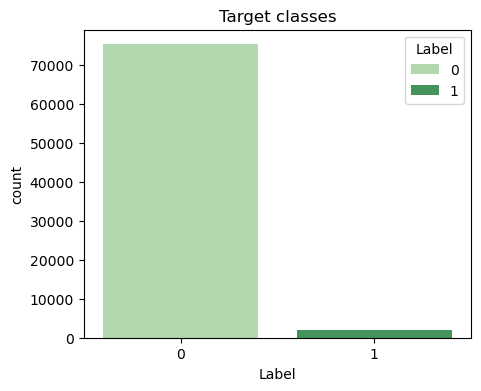

Label
0    75198
1     1895
Name: count, dtype: int64

In [13]:
# class distributions
plt.figure(figsize=(5,4))
plt.title("Target classes")
sns.countplot(data=df, x="Label", hue="Label", palette='Greens')
plt.savefig(OUTPUT_DIR / "all_CF_preds.png", dpi=500, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "all_CF_preds.pdf", bbox_inches="tight")
plt.show()

df['Label'].value_counts()

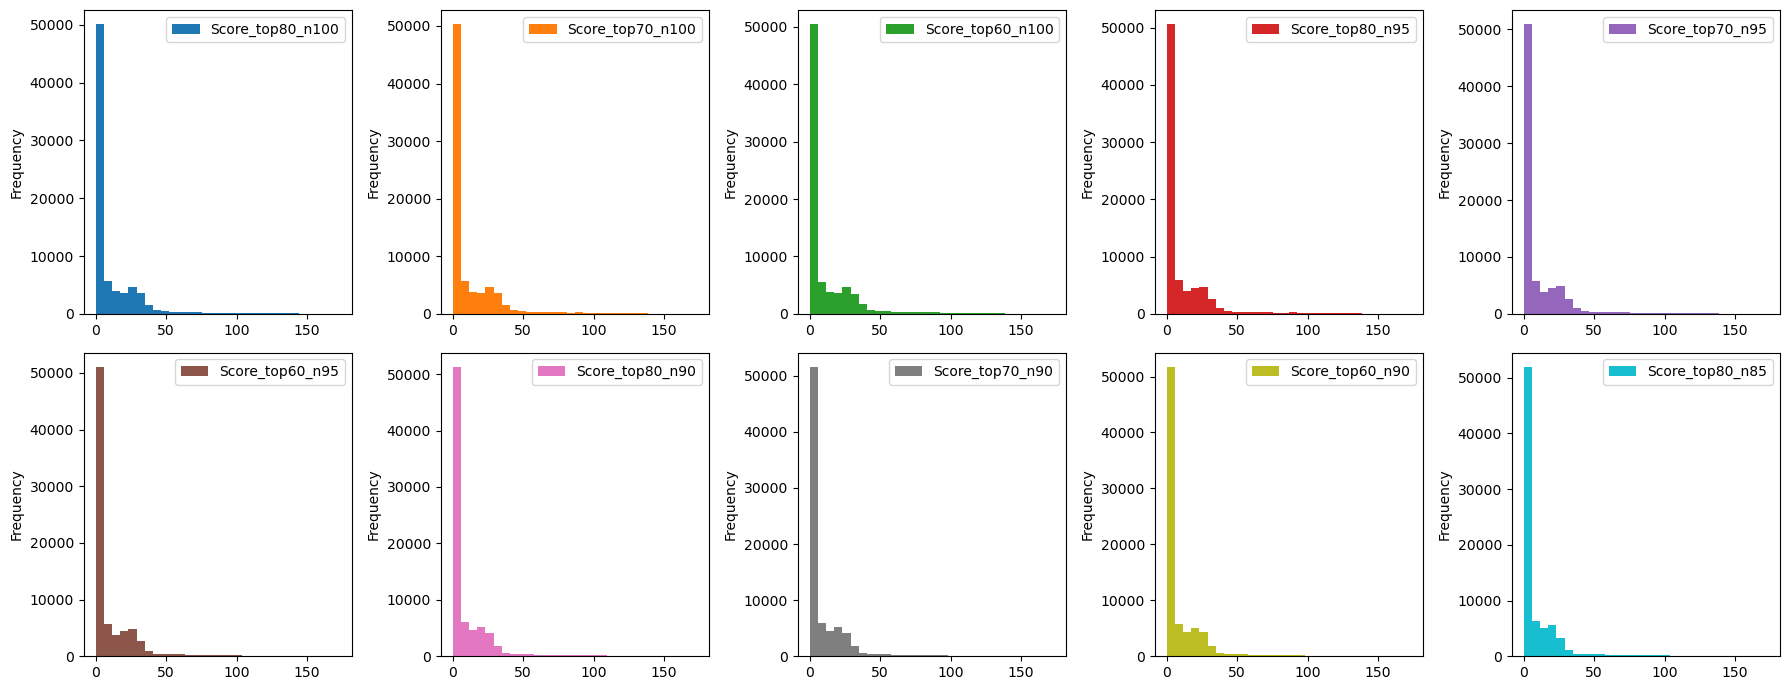

In [14]:
#variables frequency 

# finding score columns and plotting top 10 fts by variance
score_cols = [col for col in df.columns if col.startswith("Score_")]
top10_cols = (df[score_cols].var().sort_values(ascending=False).head(10).index.tolist())
df[top10_cols].plot(
    kind="hist",
    bins=30,
    subplots=True,
    layout=(2, 5),
    figsize=(18, 7),
    sharex=False,
    sharey=False
)

plt.savefig(OUTPUT_DIR / "sample_feature_distribution.png", dpi=500, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "sample_feature_distribution.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [15]:
# # Joint and marginal distributions for pairwise relationships (first 2 features)

# score_cols = [col for col in df.columns if col.startswith("Score_")]
# first2_cols = score_cols[:1]
# print("sample score features:", first2_cols)
# sns.pairplot(
#     data=df[first2_cols + ["Label"]],
#     hue="Label",
#     corner=True,
#     plot_kws={"alpha": 0.4, "s": 15}
# )
# plt.show()

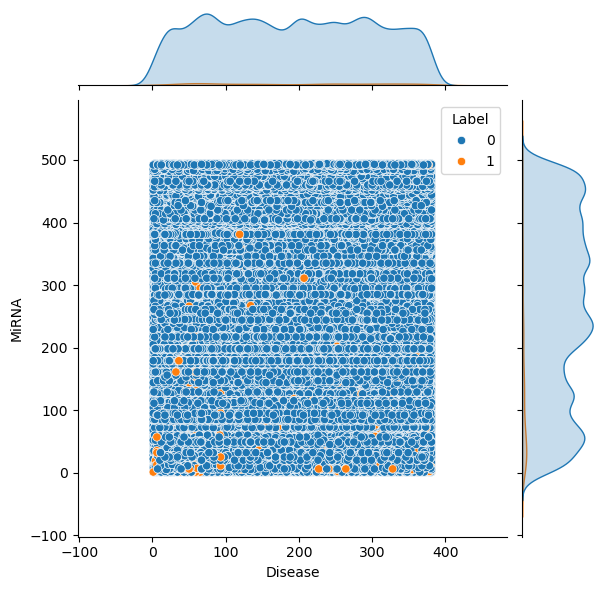

In [16]:
sns.jointplot(data=df, x="Disease", y="MiRNA", hue="Label")

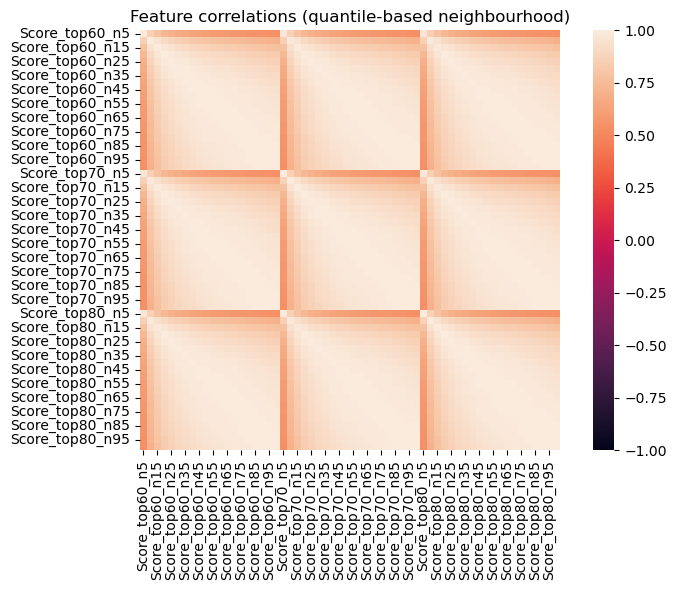

In [17]:
# feature correlation
score_cols = sorted(
    [col for col in df.columns if col.startswith("Score_top")],
    key=lambda x: (
        int(x.split("_top")[1].split("_")[0]),
        int(x.split("_n")[1])
    )
)
corr = df[score_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, square=True, vmin=-1, vmax=1)
plt.title("Feature correlations (quantile-based neighbourhood)")

plt.savefig(OUTPUT_DIR / "initial_feature_corr.png", dpi=500, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "initial_feature_corr.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

In [18]:
# upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
# values = upper.stack()

# print("Mean |r|:", values.abs().mean())
# print("Median |r|:", values.abs().median())
# print("Minimum |r|:", values.abs().min())
# print("Maximum |r|:", values.abs().max())

# print("\nPairs with |r| >= 0.90:",(values.abs() >= 0.90).sum())
# print("Pairs with |r| >= 0.95:",(values.abs() >= 0.95).sum())
# print("Pairs with |r| >= 0.99:",(values.abs() >= 0.99).sum())
# print("Total pairs:", len(values))

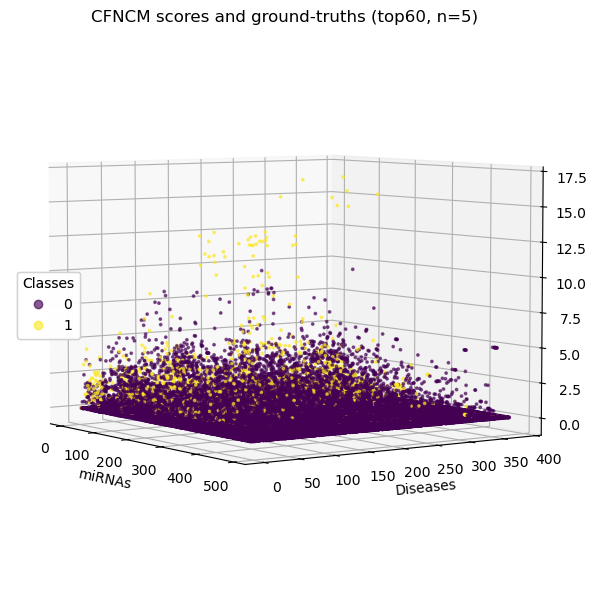

In [19]:
# CF scores and ground-truth classes for 1 sample feature (3D plot)

score_cols = [col for col in df.columns if col.startswith("Score_")]
first10_cols = score_cols[:1]
for score_col in first10_cols:
    name = score_col.replace("Score_", "").replace("_n", ", n=")
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(
        df["MiRNA"],
        df["Disease"],
        df[score_col],
        c=df["Label"],
        s=3,
        alpha=0.6
    )
    
    legend = ax.legend(*scatter.legend_elements(), loc="center left", title="Classes")
    ax.add_artist(legend)
    
    ax.set_xlabel("miRNAs")
    ax.set_ylabel("Diseases")
    ax.set_zlabel("CF score")
    ax.set_title(f"CFNCM scores and ground-truths ({name})")
    ax.view_init(elev=5, azim=-35)

    fig.savefig(OUTPUT_DIR / "sample_scores_and_ground_truths.png", dpi=500, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "sample_scores_and_ground_truths.pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [20]:
# import plotly.express as px
# import plotly.io as pio

# score_cols = [col for col in df.columns if col.startswith("Score_")]
# first10_cols = score_cols[:1]

# for score_col in first10_cols:
#     name = score_col.replace("Score_", "").replace("_n", ", n=")
#     fig = px.scatter_3d(
#         df,
#         x="MiRNA",
#         y="Disease",
#         z=score_col,
#         color=score_col,
#         title=f"MiRNA-disease association scores ({name})",
#         labels={"MiRNA": "miRNA", "Disease": "Disease", score_col: "CF score"}
#     )
#     fig.show()

In [21]:
# # CFNCM scores and ground-truth classes for the first score feature

# score_cols = [col for col in df.columns if col.startswith("Score_")]
# first10_cols = score_cols[:1]

# plot_df = df.copy()
# plot_df["Label"] = plot_df["Label"].astype(str)

# for score_col in first10_cols:
#     name = score_col.replace("Score_", "").replace("_n", ", n=")

#     fig = px.scatter_3d(
#         plot_df,
#         x="MiRNA",
#         y="Disease",
#         z=score_col,
#         color="Label",
#         title=f"CFNCM scores and ground-truth classes ({name})",
#         labels={"MiRNA": "miRNA", "Disease": "Disease", score_col: "CF score", "Label": "Class"}
#     )

#     fig.show()

In [22]:
# # checking for outliers
# fig, ax=plt.subplots(1,figsize=(8,6))
# sns.boxplot(x=df['Label'],y=df['Score'], data=df)

# plt.title("Outliers plot")
# plt.show()

In [23]:
# Negative sampling for classifier evaluation

NEGATIVE_RATIO = 1 # 1:1 pos to neg ratio

#separate known positives and unobserved/unknown pairs
positive_df = df[df["Label"] == 1].copy()
unknown_df = df[df["Label"] == 0].copy()

n_positives = len(positive_df)
n_unknowns_to_sample = n_positives * NEGATIVE_RATIO

# randomly sampling unknown pairs and combining with all known positives
sampled_unknown_df = unknown_df.sample(n=n_unknowns_to_sample, random_state=RANDOM_STATE)
sampled_df = pd.concat([positive_df, sampled_unknown_df], ignore_index=True)
sampled_df = sampled_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Full dataset:")
print(df["Label"].value_counts().sort_index())

print("\nSampled dataset:")
print(sampled_df["Label"].value_counts().sort_index())

print(f"\nTotal sampled pairs: {len(sampled_df)}; Positive prevalence: {sampled_df['Label'].mean():.4f}")

Full dataset:
Label
0    75198
1     1895
Name: count, dtype: int64

Sampled dataset:
Label
0    1895
1    1895
Name: count, dtype: int64

Total sampled pairs: 3790; Positive prevalence: 0.5000


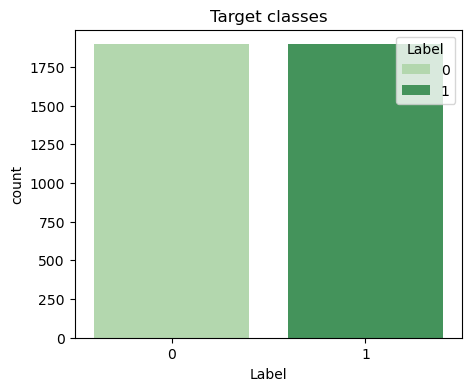

Label
1    1895
0    1895
Name: count, dtype: int64

In [24]:
# balanced class distributions
plt.figure(figsize=(5,4))
plt.title("Target classes")
sns.countplot(data=sampled_df, x="Label", hue="Label", palette='Greens')
plt.show()
sampled_df['Label'].value_counts()

In [25]:
#Construct classifier features from multi-n CF scores
score_cols = sorted(
    [col for col in df.columns if col.startswith("Score_top")],
    key=lambda x: (
        int(x.split("_n")[1].split("_")[0]),
        int(x.split("_n")[1])                 
    )
)
print("CF score features:", score_cols)

# Multi-n CF scores are the ONLY classifier features
X = sampled_df[score_cols].to_numpy(dtype=np.float32)
y = sampled_df["Label"].to_numpy(dtype=int)

print("\nFeature matrix:", X.shape)
print("Target:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())

assert np.isfinite(X).all()
assert set(np.unique(y)).issubset({0, 1})

CF score features: ['Score_top60_n5', 'Score_top70_n5', 'Score_top80_n5', 'Score_top60_n10', 'Score_top70_n10', 'Score_top80_n10', 'Score_top60_n15', 'Score_top70_n15', 'Score_top80_n15', 'Score_top60_n20', 'Score_top70_n20', 'Score_top80_n20', 'Score_top60_n25', 'Score_top70_n25', 'Score_top80_n25', 'Score_top60_n30', 'Score_top70_n30', 'Score_top80_n30', 'Score_top60_n35', 'Score_top70_n35', 'Score_top80_n35', 'Score_top60_n40', 'Score_top70_n40', 'Score_top80_n40', 'Score_top60_n45', 'Score_top70_n45', 'Score_top80_n45', 'Score_top60_n50', 'Score_top70_n50', 'Score_top80_n50', 'Score_top60_n55', 'Score_top70_n55', 'Score_top80_n55', 'Score_top60_n60', 'Score_top70_n60', 'Score_top80_n60', 'Score_top60_n65', 'Score_top70_n65', 'Score_top80_n65', 'Score_top60_n70', 'Score_top70_n70', 'Score_top80_n70', 'Score_top60_n75', 'Score_top70_n75', 'Score_top80_n75', 'Score_top60_n80', 'Score_top70_n80', 'Score_top80_n80', 'Score_top60_n85', 'Score_top70_n85', 'Score_top80_n85', 'Score_top60_n

In [26]:
X, y

(array([[ 0.6635921,  0.6635921,  0.6635921, ..., 27.406042 , 27.103924 ,
         27.349525 ],
        [ 0.       ,  0.       ,  0.       , ...,  0.7236926,  0.7236926,
          0.7236926],
        [ 0.       ,  0.       ,  0.       , ..., 32.047676 , 32.047676 ,
         32.047676 ],
        ...,
        [ 1.5437   ,  1.5437   ,  1.5437   , ..., 50.65931  , 51.615902 ,
         51.140453 ],
        [ 2.1322434,  2.1322434,  2.1322434, ..., 22.08091  , 22.7192   ,
         23.270344 ],
        [ 0.       ,  0.       ,  0.       , ..., 12.781986 , 12.688302 ,
         11.931939 ]], shape=(3790, 60), dtype=float32),
 array([1, 0, 0, ..., 0, 0, 0], shape=(3790,)))

In [27]:
# split data into training and testing sets
X = sampled_df[score_columns].values
y = sampled_df["Label"].values
indices = np.arange(len(sampled_df))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, indices, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2653, 60), (1137, 60), (2653,), (1137,))

In [28]:
print(f"Train class distribution: \n{pd.Series(y_train).value_counts()}")
print(f"Test class distribution: \n{pd.Series(y_test).value_counts()}")

Train class distribution: 
0    1327
1    1326
Name: count, dtype: int64
Test class distribution: 
1    569
0    568
Name: count, dtype: int64


In [29]:
#feature engineering: 60 cumulative + incremental features
feature_df = sampled_df.copy()
increment_columns = []
for q in [60, 70, 80]:
    for n in range(10, 101, 5):
        col = f"Increment_top{q}_n{n}"
        feature_df[col] = (feature_df[f"Score_top{q}_n{n}"] - feature_df[f"Score_top{q}_n{n-5}"])
        increment_columns.append(col)

# 60 cumulative and increments
enhanced_columns = list(score_columns) + increment_columns
X_enhanced = feature_df[enhanced_columns].values
X_train_enhanced = X_enhanced[idx_train]
X_test_enhanced = X_enhanced[idx_test]

print(f"Features: {len(enhanced_columns)} ({len(score_columns)} cumulative + {len(increment_columns)} incremental)")

Features: 117 (60 cumulative + 57 incremental)


In [30]:
# feature scaling
scaler = StandardScaler()
scaler.fit(X_train_enhanced)
X_train_scaled = scaler.transform(X_train_enhanced)
X_test_scaled = scaler.transform(X_test_enhanced)

In [31]:
X_train_scaled, X_test_scaled

(array([[-0.43923202, -0.59195791, -0.66025652, ..., -0.78098864,
         -0.81604589, -0.56695678],
        [ 0.74105176,  1.41088772,  1.57450202, ...,  0.37459122,
         -0.06560574,  0.06996729],
        [-0.43923202, -0.59195791, -0.58166191, ..., -0.51328668,
         -0.38888464, -0.67182455],
        ...,
        [-0.43923202, -0.59195791, -0.66025652, ..., -0.78098864,
         -0.49928036, -0.80933467],
        [-0.43923202, -0.59195791, -0.66025652, ..., -0.78098864,
         -0.81604589, -0.6131815 ],
        [ 0.65755635,  0.59146882,  1.1623421 , ...,  1.67368859,
          1.89791479,  1.45379559]], shape=(2653, 117)),
 array([[-0.43923202, -0.59195791, -0.66025652, ..., -0.06372821,
         -0.12296328, -0.06106759],
        [ 0.17048296,  2.07370471,  2.55069108, ...,  0.50491718,
          0.32493477,  0.7605566 ],
        [-0.43923202, -0.59195791, -0.66025652, ..., -0.78098864,
         -0.81604589, -0.80933467],
        ...,
        [-0.43923202, -0.59195791, 

###  Classifiers

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import BaggingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

In [33]:
# Main helper functions

# plotting ROC and PR curves
def plot_sklearn_roc_curve(y_test, y_score):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    auprc = average_precision_score(y_test, y_score)
    baseline_auprc = np.mean(y_test)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(fpr, tpr, label=f"AUROC = {roc_auc:.4f}")
    ax1.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC curve")
    ax1.legend(loc="lower right")

    ax2.plot(recall, precision, label=f"AUPRC = {auprc:.4f}")
    ax2.axhline(baseline_auprc, linestyle="--", label=f"Baseline = {baseline_auprc:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-recall curve")
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()

    return roc_auc, auprc

# fitting classifier and evaluating against ground-truths
def classification_model(model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)

    y_score_train = model.predict_proba(X_train)[:, 1]
    y_score_test = model.predict_proba(X_test)[:, 1]

    # fixed threshold
    y_pred_train = (y_score_train >= threshold).astype(int)
    y_pred = (y_score_test >= threshold).astype(int)
    print(f"Classification threshold: {threshold:.4f}")

    # calculating accuracy
    training_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Training accuracy: {training_acc:.4f}")
    print(f"Test accuracy:     {test_acc:.4f}")

    # confucion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print("\nConfusion matrix:")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=True, linewidths=.5, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion matrix (threshold = {threshold:.2f})")
    plt.tight_layout()
    plt.show()

    # classification report
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # threshold-dependent metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision_value = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_value = sensitivity

    f1 = (
        2 * precision_value * recall_value /
        (precision_value + recall_value)
        if (precision_value + recall_value) > 0
        else 0.0
    )
    print(f"Sensitivity: {sensitivity:.4f}; Specificity: {specificity:.4f}")
    print(f"Precision: {precision_value:.4f}; Recall:      {recall_value:.4f}")
    print(f"F1-score: {f1:.4f}")

    # threshold-based metrics
    roc_auc, auprc = plot_sklearn_roc_curve(y_test, y_score_test)
    print(f"\nAUROC: {roc_auc:.5f}")
    print(f"AUPRC: {auprc:.5f}")

    return {"Threshold": threshold, "Training Accuracy": training_acc, "Test Accuracy": test_acc, "Precision": precision_value,
            "Recall": recall_value, "F1": f1, "Sensitivity": sensitivity, "Specificity": specificity, "AUROC": roc_auc, "AUPRC": auprc,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp}

Classification threshold: 0.5000
Training accuracy: 0.8078
Test accuracy:     0.8030

Confusion matrix:
[[529  39]
 [185 384]]


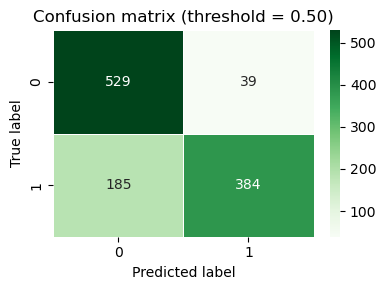


Classification report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.83       568
           1       0.91      0.67      0.77       569

    accuracy                           0.80      1137
   macro avg       0.82      0.80      0.80      1137
weighted avg       0.82      0.80      0.80      1137

Sensitivity: 0.6749; Specificity: 0.9313
Precision: 0.9078; Recall:      0.6749
F1-score: 0.7742


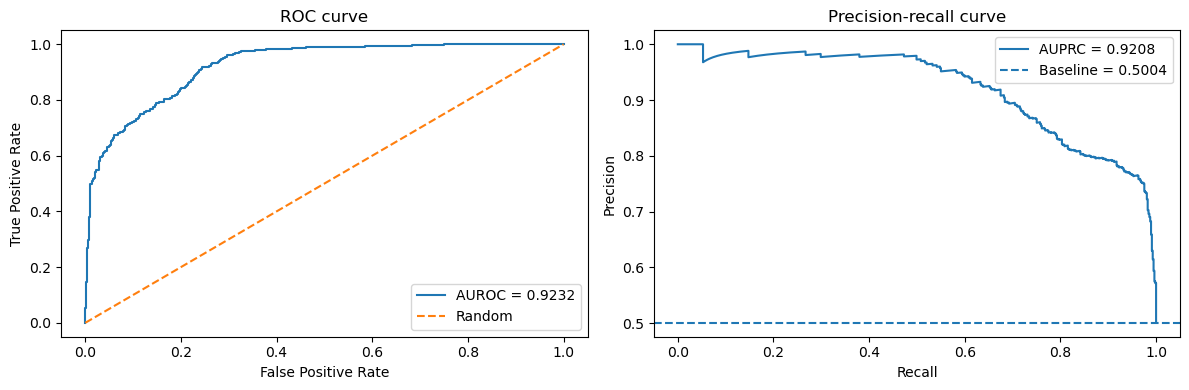


AUROC: 0.92322
AUPRC: 0.92079
Best LR parameters: {'estimator__C': 0.5, 'estimator__penalty': 'l2', 'estimator__solver': 'liblinear'}
Best CV AUPRC: 0.9081319087646712


In [34]:
# Logistic regression classifier

base_lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

lr_model = BaggingClassifier(
    estimator=base_lr,
    n_estimators=500,
    max_samples=0.40,
    max_features=0.30,
    bootstrap=True,
    bootstrap_features=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lr_param_grid = {
    # LR params
    "estimator__C": [0.001, 0.001, 0.5],
    "estimator__penalty": ["l1", "l2"],
    "estimator__solver": ["liblinear"],
}
lr_model_GS = GridSearchCV(
    estimator=lr_model, 
    param_grid=lr_param_grid, 
    cv=10, 
    scoring={'AUROC': "roc_auc", "AUPRC": "average_precision"}, 
    refit="AUPRC", 
    n_jobs=-1
)

lr_results = classification_model(
    lr_model_GS,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=0.5
)

print("Best LR parameters:", lr_model_GS.best_params_)
print("Best CV AUPRC:", lr_model_GS.best_score_)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=5, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=5, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=5, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=10, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=5, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=10, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=10, n_estimators=5; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, min_samples_leaf=5, min_samples_split=10, n_estimators=10; total time=   0.1s
[C

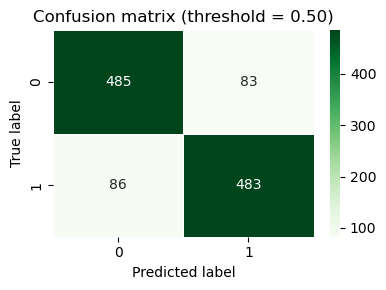


Classification report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       568
           1       0.85      0.85      0.85       569

    accuracy                           0.85      1137
   macro avg       0.85      0.85      0.85      1137
weighted avg       0.85      0.85      0.85      1137

Sensitivity: 0.8489; Specificity: 0.8539
Precision: 0.8534; Recall:      0.8489
F1-score: 0.8511


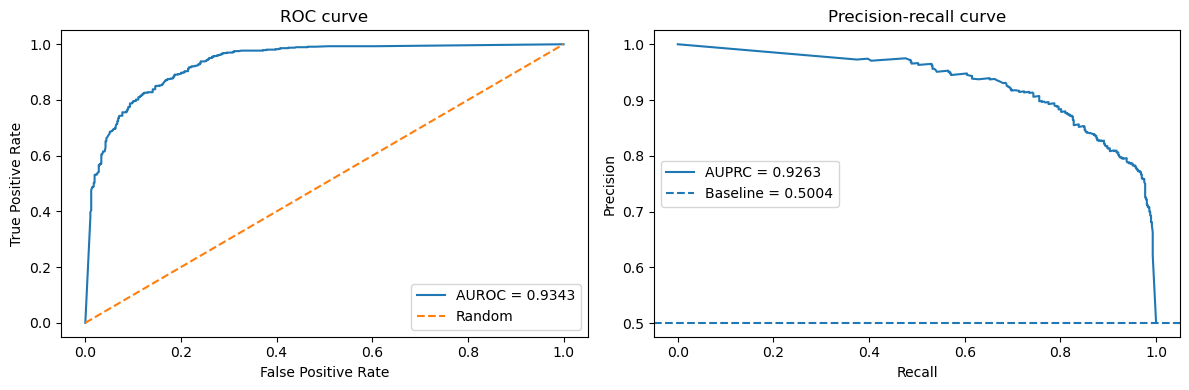


AUROC: 0.93431
AUPRC: 0.92625
Best Random Forest parameters: {'max_depth': 3, 'max_features': 0.2, 'min_samples_leaf': 15, 'min_samples_split': 5, 'n_estimators': 10}
Best CV AUPRC: 0.9134364212312598


In [35]:
#Random forest classifier
rf_param_grid = {
    "n_estimators": [5, 10],
    "max_depth": [2, 3],
    "min_samples_leaf": [5, 10, 15],
    "min_samples_split": [5, 10, 20],
    "max_features": [0.2, 0.4, 0.6]
}

rf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_model_GS = GridSearchCV(
    estimator=rf_model, 
    param_grid=rf_param_grid, 
    cv=10, 
    # scoring="average_precision",
    scoring={'AUROC': "roc_auc", "AUPRC": "average_precision"},
    refit="AUPRC",
    n_jobs=-1, 
    verbose=2
    )

rf_results = classification_model(
    rf_model_GS,
    X_train_enhanced,
    X_test_enhanced,
    y_train,
    y_test,
    threshold=0.5
)

print("Best Random Forest parameters:", rf_model_GS.best_params_)
print("Best CV AUPRC:", rf_model_GS.best_score_)

Classification threshold: 0.5000
Training accuracy: 0.9774
Test accuracy:     0.8892

Confusion matrix:
[[501  67]
 [ 59 510]]


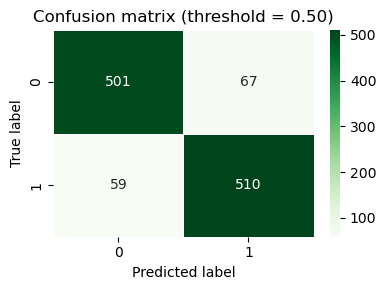


Classification report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       568
           1       0.88      0.90      0.89       569

    accuracy                           0.89      1137
   macro avg       0.89      0.89      0.89      1137
weighted avg       0.89      0.89      0.89      1137

Sensitivity: 0.8963; Specificity: 0.8820
Precision: 0.8839; Recall:      0.8963
F1-score: 0.8901


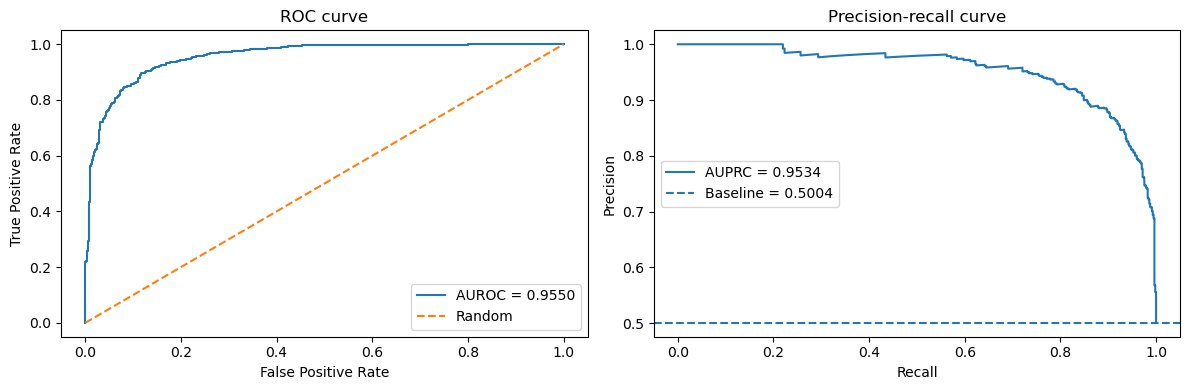


AUROC: 0.95501
AUPRC: 0.95337


In [40]:
# SVM classifier 
# (GridSearchCV was used to obtain the optimum parameters used in this final run)

svm = make_pipeline(
    PowerTransformer(),
    BaggingClassifier(
        estimator=SVC(
            kernel="rbf",
            C=500,
            gamma=0.005,
            class_weight={0: 1.0, 1: 1.5},
            probability=True,
            random_state=RANDOM_STATE
        ),
        n_estimators=100,
        max_features=0.50,
        max_samples=0.90,
        bootstrap=False,
        bootstrap_features=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
)

hgb = HistGradientBoostingClassifier(
    learning_rate=0.005,
    max_iter=1000,
    max_leaf_nodes=50,
    max_depth=None,
    min_samples_leaf=5,
    l2_regularization=0.70,
    random_state=RANDOM_STATE
)

enhanced_svm = VotingClassifier(
    estimators=[
        ("svm", svm),
        ("extra", ExtraTreesClassifier(
            n_estimators=100,
            max_features="sqrt",
            min_samples_leaf=2,
            max_depth=30,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )),
        ("hgb", hgb)
    ],
    voting="soft",
    weights=[0.555, 0.175, 0.425],
    n_jobs=-1
)

svm_classifier_results = classification_model(
    enhanced_svm,
    X_train_enhanced,
    X_test_enhanced,
    y_train,
    y_test,
    threshold=0.5
)

In [41]:
# model performance summary table
results_df = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "SVM": svm_classifier_results,
}).T

display(results_df.round(4))

,Threshold,Training Accuracy,Test Accuracy,Precision,Recall,F1,Sensitivity,Specificity,AUROC,AUPRC,TN,FP,FN,TP
Logistic Regression,0.5,0.8078,0.8030,0.9078,0.6749,0.7742,0.6749,0.9313,0.9232,0.9208,529.0,39.0,185.0,384.0
Random Forest,0.5,0.8364,0.8514,0.8534,0.8489,0.8511,0.8489,0.8539,0.9343,0.9263,485.0,83.0,86.0,483.0
SVM,0.5,0.9774,0.8892,0.8839,0.8963,0.8901,0.8963,0.8820,0.9550,0.9534,501.0,67.0,59.0,510.0


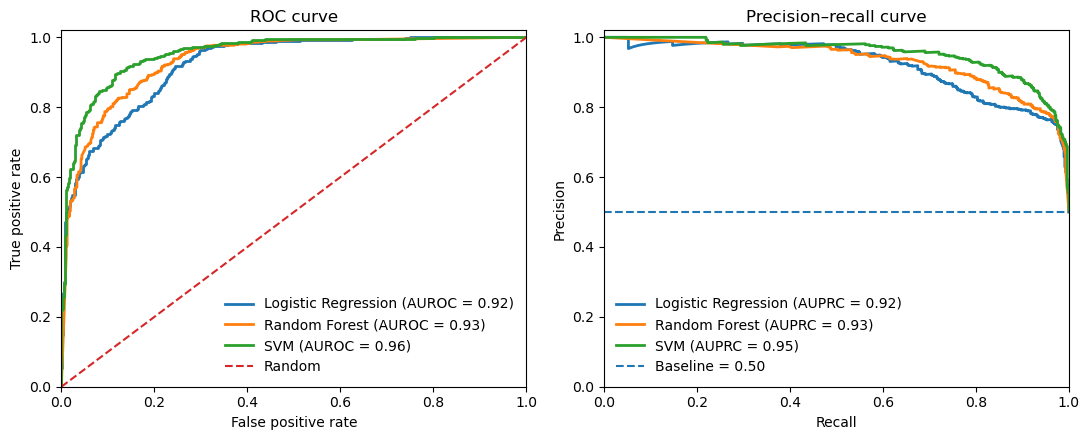

In [42]:
# performance curves (AUC and AUPRC)
model_scores = {
    "Logistic Regression": lr_model_GS.predict_proba(X_test_scaled)[:, 1],
    "Random Forest": rf_model_GS.predict_proba(X_test_enhanced)[:, 1],
    "SVM": enhanced_svm.predict_proba(X_test_enhanced)[:, 1],
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
for model_name, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    model_auc = roc_auc_score(y_test, y_score)
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUROC = {model_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
for model_name, y_score in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    model_auprc = average_precision_score(y_test, y_score)
    ax.plot(recall, precision, linewidth=2, label=f"{model_name} (AUPRC = {model_auprc:.2f})")

baseline_auprc = y_test.mean()
ax.axhline(
    baseline_auprc,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline = {baseline_auprc:.2f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–recall curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "AUC_AUPRC_curves.png", dpi=500, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "AUC_AUPRC_curves.pdf", bbox_inches="tight")
plt.show()

In [39]:
# saving SVM prediction rankings
y_score = enhanced_svm.predict_proba(X_test_enhanced)[:, 1]
ranking_df = df.iloc[idx_test][["MiRNA", "Disease"]].copy()
ranking_df["Score"] = y_score
ranking_df = ranking_df.sort_values("Score", ascending=False).reset_index(drop=True)
ranking_df.to_csv("SVM_prediction_ranking.csv", index=False)

display(ranking_df)

,MiRNA,Disease,Score
0,119,23,0.974781
1,421,295,0.967862
2,310,152,0.964364
3,37,199,0.963730
4,148,246,0.962825
...,...,...,...
1132,10,142,0.033196
1133,146,96,0.032759
1134,65,279,0.032759
1135,75,111,0.030234
